#Name: Aliza Lama
#Student ID: 2408583
#7 Exercise.
#Implement an End to End CNN Model for Image Classification Task.
#Task 1: Data Understanding and Visualization:

In [2]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/AI&ML/data/FruitinAmazon.zip'
data_path = '/content/drive/MyDrive/AI ML 2026/data'
destination_directory = os.path.dirname(data_path)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(destination_directory)

print(f"Successfully unzipped '{zip_file_path}' to '{destination_directory}'")

Successfully unzipped '/content/drive/MyDrive/AI&ML/data/FruitinAmazon.zip' to '/content/drive/MyDrive/AI ML 2026'


#Task 1: Data Understanding and Visualization:

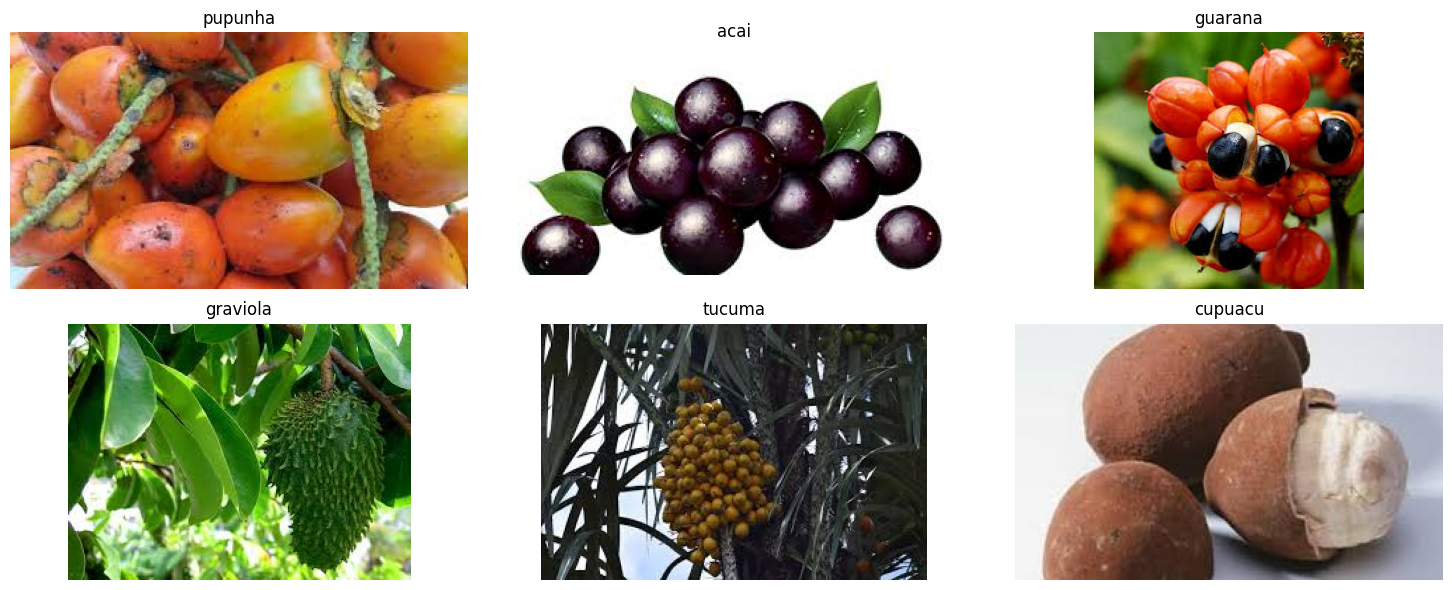

No corrupted images found.


In [3]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
train_dir = "/content/drive/MyDrive/AI ML 2026/FruitinAmazon/train"

#Get class folders
classes = [cls for cls in os.listdir(train_dir) if not cls.startswith('.')]

#Lists for visualization
images = []
labels = []

#Corrupted image tracking
corrupted_images = []

#Loop through each class
for cls in classes:
    class_path = os.path.join(train_dir, cls)

    img_files = [img for img in os.listdir(class_path) if not img.startswith('.')]

    valid_images = []

    for img_name in img_files:
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()  # check corruption
            valid_images.append(img_name)
        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

    #Pick random image from valid ones
    if valid_images:
        chosen_img = random.choice(valid_images)
        img_path = os.path.join(class_path, chosen_img)
        img = Image.open(img_path)

        images.append(img)
        labels.append(cls)

#Display images in 2 rows
num_images = len(images)
cols = (num_images + 1) // 2

plt.figure(figsize=(15, 6))

for i in range(num_images):
    plt.subplot(2, cols, i + 1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# Final message
if len(corrupted_images) == 0:
    print("No corrupted images found.")
else:
    print(f"Total corrupted images removed: {len(corrupted_images)}")

#Task 2: Loading and Preprocessing Image Data in keras:

In [4]:
import tensorflow as tf

# Dataset path
train_dir = "/content/drive/MyDrive/AI ML 2026/FruitinAmazon/train"

# Parameters
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

#Normalization layer (0–255 ➜ 0–1)
rescale = tf.keras.layers.Rescaling(1./255)

#Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

#Apply normalization
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

#Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

#Apply normalization
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

#Check output
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)


#Task 3 - Implement a CNN with
#Follow the following Structure and Hyper - parameters:

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
import os
train_dir = "/content/drive/MyDrive/AI ML 2026/FruitinAmazon/train"
num_classes = len([d for d in os.listdir(train_dir) if not d.startswith('.')])
print("Number of classes:", num_classes)

#Build CNN model
model = models.Sequential([

    # Convolutional Layer 1
    layers.Conv2D(32, (3, 3), strides=1, padding='same', activation='relu', input_shape=(128,128,3)),
    # Pooling Layer 1
    layers.MaxPooling2D(pool_size=(2,2), strides=2),

    # Convolutional Layer 2
    layers.Conv2D(32, (3,3), strides=1, padding='same', activation='relu'),
    # Pooling Layer 2
    layers.MaxPooling2D(pool_size=(2,2), strides=2),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layers
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

#Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Model summary
model.summary()

Number of classes: 6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

#Task 4: Compile the Model
#Task 4: Train the Model

In [8]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Callbacks
checkpoint_cb = ModelCheckpoint(
    "best_model.h5",    # save the best model
    save_best_only=True,
    monitor="val_accuracy",
    mode="max",
    verbose=1
)

earlystop_cb = EarlyStopping(
    monitor="val_loss",
    patience=20,        # stop training if no improvement for 20 epochs
    restore_best_weights=True,
    verbose=1
)

# 🔹 Train the model
history = model.fit(
    train_ds,           # training dataset
    validation_data=val_ds,
    epochs=250,
    batch_size=16,      # batch size
    callbacks=[checkpoint_cb, earlystop_cb]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.1140 - loss: 1.7883
Epoch 1: val_accuracy improved from None to 0.83333, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 375ms/step - accuracy: 0.1389 - loss: 1.8295 - val_accuracy: 0.8333 - val_loss: 1.2841
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.3588 - loss: 1.5666
Epoch 2: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 289ms/step - accuracy: 0.3889 - loss: 1.5503 - val_accuracy: 0.2222 - val_loss: 1.5481
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.6453 - loss: 1.2551
Epoch 3: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 298ms/step - accuracy: 0.6389 - loss: 1.2240 - val_accuracy: 0.1111 - val_loss: 1.7647
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.5932 - loss: 0.9866
Epoch 4: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 311ms/step - accuracy: 0.6389 - loss: 0.9361 - val_accuracy: 0.5000 - val_loss: 1.1101
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.8241 - loss: 0.698


Epoch 21: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 327ms/step - accuracy: 1.0000 - loss: 6.7625e-04 - val_accuracy: 0.8889 - val_loss: 0.2488
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 1.0000 - loss: 6.8137e-04
Epoch 22: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 306ms/step - accuracy: 1.0000 - loss: 6.2476e-04 - val_accuracy: 0.8889 - val_loss: 0.2421
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 1.0000 - loss: 5.3138e-04
Epoch 23: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 280ms/step - accuracy: 1.0000 - loss: 5.6087e-04 - val_accuracy: 0.8889 - val_loss: 0.2375
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 1.0000 - loss: 5.3358e-04
Epoch 24: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 285ms/step - accuracy: 1.0000 - loss: 5.0157e-04 - val_accuracy: 0.8889 - val_loss: 0.2378
Epoch 25/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/s

#Task 5: Evaluate the Model

In [13]:
import tensorflow as tf

#Path to test dataset
test_dir = "/content/drive/MyDrive/AI ML 2026/FruitinAmazon/test"

#Create test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(128, 128),
    batch_size=16,
    shuffle=False
)

#Normalize pixel values
rescale = tf.keras.layers.Rescaling(1./255)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

#Evaluate the model on test set
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 30 files belonging to 6 classes.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7000 - loss: 1.0874 
Test Loss: 1.0874
Test Accuracy: 0.7000


#Task 6: Save and Load the Model

In [14]:
import tensorflow as tf

#Path to save the model
model_path = "/content/drive/MyDrive/AI ML 2026/FruitinAmazon/best_cnn_model.h5"

#Save the trained model
model.save(model_path)
print(f"Model saved to: {model_path}")

#Load the saved model
loaded_model = tf.keras.models.load_model(model_path)
print("Model loaded successfully.")

# Evaluate the loaded model on test dataset
test_loss, test_accuracy = loaded_model.evaluate(test_ds)

print(f"Test Loss (loaded model): {test_loss:.4f}")
print(f"Test Accuracy (loaded model): {test_accuracy:.4f}")

Model saved to: /content/drive/MyDrive/AI ML 2026/FruitinAmazon/best_cnn_model.h5
Model loaded successfully.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7000 - loss: 1.0874 
Test Loss (loaded model): 1.0874
Test Accuracy (loaded model): 0.7000


In [15]:
import numpy as np
from sklearn.metrics import classification_report

# 🔹 Get true labels from test dataset
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

# 🔹 Make predictions
y_pred_probs = loaded_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)  # convert probabilities to class labels

# 🔹 Generate classification report
report = classification_report(y_true, y_pred, target_names=[d for d in os.listdir(train_dir) if not d.startswith('.')])
print("Classification Report:\n")
print(report)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 235ms/step
Classification Report:

              precision    recall  f1-score   support

     pupunha       0.75      0.60      0.67         5
        acai       0.43      0.60      0.50         5
     guarana       0.62      1.00      0.77         5
    graviola       1.00      0.60      0.75         5
      tucuma       0.83      1.00      0.91         5
     cupuacu       1.00      0.40      0.57         5

    accuracy                           0.70        30
   macro avg       0.77      0.70      0.69        30
weighted avg       0.77      0.70      0.69        30



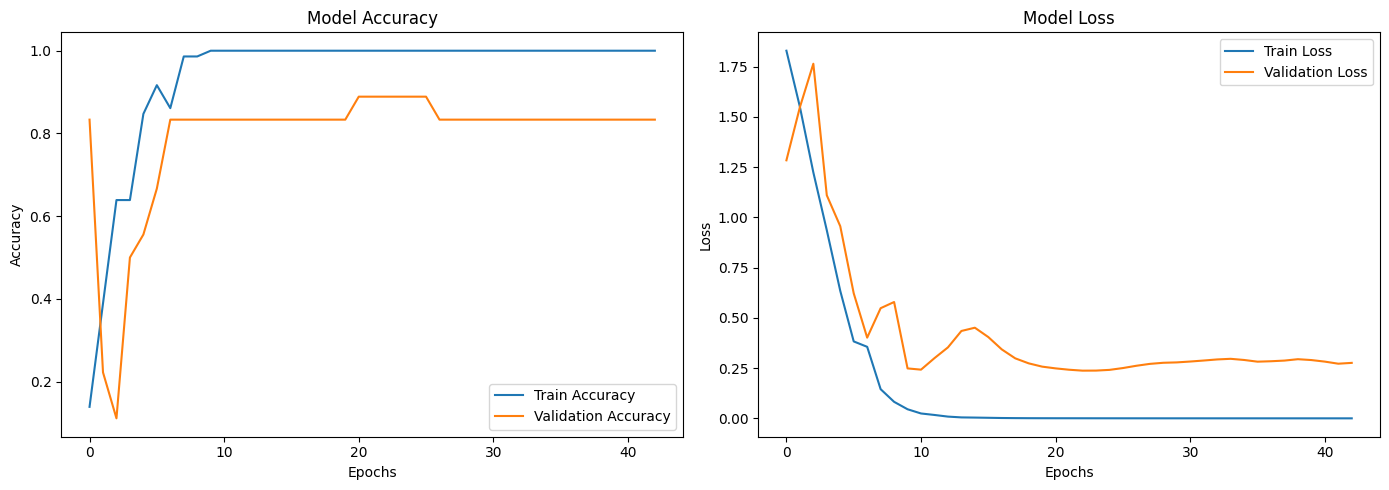

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7000 - loss: 1.0874 

Test Loss: 1.0874
Test Accuracy: 0.7000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step 

Classification Report:

              precision    recall  f1-score   support

     pupunha       0.75      0.60      0.67         5
        acai       0.43      0.60      0.50         5
     guarana       0.62      1.00      0.77         5
    graviola       1.00      0.60      0.75         5
      tucuma       0.83      1.00      0.91         5
     cupuacu       1.00      0.40      0.57         5

    accuracy                           0.70        30
   macro avg       0.77      0.70      0.69        30
weighted avg       0.77      0.70      0.69        30



In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
import os

#Plot training & validation accuracy and loss
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

#Evaluate on test set
test_loss, test_accuracy = loaded_model.evaluate(test_ds)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

#Get true labels
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

#Make predictions
y_pred_probs = loaded_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification report
class_names = [d for d in os.listdir(train_dir) if not d.startswith('.')]
report = classification_report(y_true, y_pred, target_names=class_names)
print("\nClassification Report:\n")
print(report)